# 04. 심화 실습 2: 전체 통합 쇼핑 추천 Agent

---

## 학습 목표

01~03에서 배운 **모든 패턴을 하나로 통합**하는 실전 에이전트를 만듭니다.

## 이제까지 배운 것

```text
01_basic       START → [검색] → [추천] → END                    (순차 실행)
02_parallel    START → [A검색][B검색][C검색] → [통합] → ...    (병렬 실행)
03_conditional START → [검색] → [평가] → (충분?) → [추천]      (조건부 + 루프)
                                       ↓ 부족
                                  [재작성] → [검색]
```

## 이번 노트북: 모두 통합

```text
START
  → [요청분석]
  → [키워드A검색] (병렬)   ← 02에서 배운 fan-out
  → [키워드B검색] (병렬)   ← 02에서 배운 fan-out
  → [통합필터링]            ← 02에서 배운 fan-in
  → [결과평가]
  → (충분) → [추천리포트] → END
  → (부족) → [검색보완] → [보완검색] → [통합필터링]  ← 03에서 배운 루프
```

In [2]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

import os
import re
import operator
import requests
from html import unescape
from typing import TypedDict, List, Annotated

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# LLM 모델 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
print("준비 완료")

준비 완료


In [3]:
def search_naver_shopping(query: str, display: int = 5, sort: str = "sim") -> list[dict]:
    """
    네이버 쇼핑 API로 상품을 검색한다.
    sort: sim(관련도), asc(낮은가격), dsc(높은가격)
    """
    url = "https://openapi.naver.com/v1/search/shop.json"

    # API 인증 헤더 설정
    headers = {
        "X-Naver-Client-Id":     os.environ["NAVER_CLIENT_ID"],
        "X-Naver-Client-Secret": os.environ["NAVER_CLIENT_SECRET"],
    }

    # 검색 파라미터 설정
    params = {"query": query, "display": display, "start": 1, "sort": sort}

    # API 호출
    resp = requests.get(url, headers=headers, params=params, timeout=10)
    resp.raise_for_status()  # HTTP 오류 시 예외 발생

    # 응답에서 상품 목록 추출
    result = []
    for item in resp.json().get("items", []):
        # HTML 태그와 특수문자 제거 (예: <b>상품명</b> → 상품명)
        clean_title = re.sub(r"<[^>]+>", "", unescape(item.get("title", "")))
        result.append({
            "title":  clean_title,
            "link":   item.get("link", ""),
            "lprice": int(item.get("lprice", 0) or 0),  # 최저가 (없으면 0)
            "mall":   item.get("mallName", ""),
        })
    return result

print("API 래퍼 정의 완료")

API 래퍼 정의 완료


---

## Step 1. State 정의

이번 State에는 01~03의 모든 개념이 담겨 있습니다.

| 필드 | 설명 | 관련 패턴 |
|---|---|---|
| `keyword_a`, `keyword_b` | LLM이 추출한 검색어 2개 | 이번 추가 |
| `all_products` | `Annotated[..., operator.add]` 병렬 결과 자동 누적 | 02 패턴 |
| `filtered_products` | 중복 제거 + 가격순 정렬된 상품 | 이번 추가 |
| `is_sufficient` | 결과 충분 여부 → 분기 기준 | 03 패턴 |
| `retry_count` | 루프 횟수 제한 | 03 패턴 |

In [4]:
MAX_RETRY = 1  # 보완 검색은 최대 1회

class IntegratedShoppingState(TypedDict):
    question:          str                                  # 원본 질문
    keyword_a:         str                                  # 검색어 A (구체적)
    keyword_b:         str                                  # 검색어 B (넓은 범위)
    all_products:      Annotated[List[dict], operator.add]  # 병렬 결과 자동 누적
    filtered_products: List[dict]                           # 중복 제거 + 정렬된 상품
    is_sufficient:     bool                                 # 결과 충분 여부
    answer:            str                                  # 최종 추천 답변
    retry_count:       int                                  # 보완 검색 횟수

print("State 필드:", list(IntegratedShoppingState.__annotations__.keys()))
print()
print("※ all_products: Annotated 리듀서 → 병렬 검색 결과가 자동으로 합산됨")
print("※ retry_count : MAX_RETRY 초과 시 루프 강제 종료")

State 필드: ['question', 'keyword_a', 'keyword_b', 'all_products', 'filtered_products', 'is_sufficient', 'answer', 'retry_count']

※ all_products: Annotated 리듀서 → 병렬 검색 결과가 자동으로 합산됨
※ retry_count : MAX_RETRY 초과 시 루프 강제 종료


---

## Step 2. 노드 정의 (8개)

```text
요청분석
  ↓ fan-out
키워드A검색    키워드B검색   (병렬 동시 실행)
  ↓                ↓
  ↘              ↙  fan-in
    통합필터링
       ↓
    결과평가 ──(충분)──→ 추천리포트 → END
       ↓ (부족)
    키워드보완
       ↓
    보완검색 ──────────→ 통합필터링  (루프)
```

In [5]:
# ── 노드 1: 요청분석 ──────────────────────────────────────────
# 사용자 질문에서 검색어 2개를 추출하는 프롬프트
analyze_prompt = ChatPromptTemplate.from_messages([
    ("system", """사용자 쇼핑 질문에서 네이버 쇼핑 검색어 2개를 추출하세요.
- 검색어1: 구체적인 키워드 (브랜드명, 모델명 포함)
- 검색어2: 더 넓은 카테고리 키워드

형식 (두 줄만 출력):
검색어1: [키워드]
검색어2: [키워드]"""),
    ("human", "질문: {question}")
])

def analyze_node(state: IntegratedShoppingState) -> dict:
    """질문에서 검색어 2개를 추출한다"""
    print("  [요청분석] 키워드 추출 중...")

    # 체인 정의: 프롬프트 → LLM → 텍스트 파서
    chain = analyze_prompt | llm | StrOutputParser()

    # 체인 실행: LLM이 검색어 2개를 추출
    output = chain.invoke({"question": state["question"]})

    # LLM 출력을 줄 단위로 파싱해서 검색어 추출
    keyword_a = keyword_b = state["question"]  # 기본값: 원본 질문
    for line in output.strip().splitlines():
        if line.startswith("검색어1:"):
            keyword_a = line.split(":", 1)[1].strip()
        elif line.startswith("검색어2:"):
            keyword_b = line.split(":", 1)[1].strip()

    print(f"  [요청분석] A='{keyword_a}' / B='{keyword_b}'")
    return {"keyword_a": keyword_a, "keyword_b": keyword_b}

In [6]:
# ── 노드 2: 키워드A 검색 (관련도순) ──────────────────────────
def search_a_node(state: IntegratedShoppingState) -> dict:
    """키워드A로 관련도 순 검색"""
    print(f"  [키워드A검색] '{state['keyword_a']}' (관련도순)")

    # 관련도순(sim)으로 검색
    products = search_naver_shopping(state["keyword_a"], display=5, sort="sim")
    print(f"  [키워드A검색] {len(products)}개")

    # operator.add 리듀서에 의해 all_products에 자동 누적됨
    return {"all_products": products}


# ── 노드 3: 키워드B 검색 (가격순) ────────────────────────────
def search_b_node(state: IntegratedShoppingState) -> dict:
    """키워드B로 가격 오름차순 검색"""
    print(f"  [키워드B검색] '{state['keyword_b']}' (가격순)")

    # 가격 낮은순(asc)으로 검색
    products = search_naver_shopping(state["keyword_b"], display=5, sort="asc")
    print(f"  [키워드B검색] {len(products)}개")

    # operator.add 리듀서에 의해 all_products에 자동 누적됨
    return {"all_products": products}


print("병렬 검색 노드 2개 정의 완료")

병렬 검색 노드 2개 정의 완료


In [7]:
# ── 노드 4: 통합필터링 ────────────────────────────────────────
def filter_node(state: IntegratedShoppingState) -> dict:
    """all_products에서 중복 제거 후 가격순 정렬"""
    # URL(link) 기준으로 중복 제거
    seen   = set()
    unique = []
    for p in state["all_products"]:
        if p["link"] not in seen:
            seen.add(p["link"])
            unique.append(p)

    # 가격 낮은순으로 정렬
    filtered = sorted(unique, key=lambda x: x["lprice"])
    print(f"  [통합필터링] {len(state['all_products'])}개 → 중복제거 후 {len(filtered)}개")
    return {"filtered_products": filtered}

In [8]:
# ── 노드 5: 결과평가 ──────────────────────────────────────────
def evaluate_node(state: IntegratedShoppingState) -> dict:
    """filtered_products 수로 충분 여부 판단"""
    count      = len(state["filtered_products"])
    sufficient = count >= 5  # 5개 이상이면 충분하다고 판단
    retry      = state.get("retry_count", 0)

    print(f"  [결과평가] {count}개, 보완={retry}회 → {'✅ 충분' if sufficient else '❌ 부족'}")
    return {"is_sufficient": sufficient}

In [17]:
# ── 노드 6: 키워드 보완 (새 키워드 생성) ───────────────────────
# 기존 두 키워드를 합쳐 더 넓은 검색어를 만드는 프롬프트
supplement_prompt = ChatPromptTemplate.from_messages([
    ("system", """검색 결과가 부족합니다.
두 키워드를 참고하여 더 넓고 일반적인 보완 검색어를 1개 만드세요.
검색어만 출력하세요."""),
    ("human", "원본 질문: {question}\n키워드A: {keyword_a}\n키워드B: {keyword_b}")
])

def supplement_node(state: IntegratedShoppingState) -> dict:
    """결과 부족 시 보완 검색어를 생성한다"""
    # 체인 정의: 프롬프트 → LLM → 텍스트 파서
    chain = supplement_prompt | llm | StrOutputParser()

    # 체인 실행: LLM이 새 보완 검색어를 생성
    new_query = chain.invoke({
        "question":  state["question"],
        "keyword_a": state["keyword_a"],
        "keyword_b": state["keyword_b"],
    }).strip()  # 앞뒤 공백 제거

    # 재시도 횟수 증가
    retry = state.get("retry_count", 0) + 1
    print(f"  [키워드보완] 새 키워드: '{new_query}' ({retry}회차)")
    return {"keyword_a": new_query, "retry_count": retry}


# ── 노드 7: 보완검색 ──────────────────────────────────────────
def supplement_search_node(state: IntegratedShoppingState) -> dict:
    """보완 키워드로 추가 검색한다"""
    print(f"  [키워드보완] '{state['keyword_a']}'")

    # 보완 키워드로 API 호출
    products = search_naver_shopping(state["keyword_a"], display=5)
    print(f"  [보완검색] {len(products)}개 추가")

    # operator.add 리듀서로 기존 all_products에 누적됨
    return {"all_products": products}


print("보완 검색 노드 2개 정의 완료")

보완 검색 노드 2개 정의 완료


In [10]:
# ── 노드 8: 추천리포트 ────────────────────────────────────────
# 최종 추천 리포트를 생성하는 프롬프트
recommend_prompt = ChatPromptTemplate.from_messages([
    ("system", """아래 네이버 쇼핑 검색 결과를 바탕으로 상품을 추천하세요.

### 추천 상품 TOP 5
(순위, 상품명, 가격, 쇼핑몰, 링크)

### 구매 가이드
(가격대 요약, 선택 시 유의사항 1~2줄)"""),
    ("human", "요청: {question}\n\n검색 결과:\n{products}")
])

def recommend_node(state: IntegratedShoppingState) -> dict:
    """최종 추천 리포트를 생성한다"""
    print("  [추천리포트] 작성 중...")

    # 상품 목록을 LLM이 읽기 쉬운 텍스트로 변환 (최대 10개)
    lines = []
    for i, p in enumerate(state["filtered_products"][:10]):
        line = f"[{i+1}] {p['title'][:45]} | {p['lprice']:,}원 | {p['mall']} | {p['link']}"
        lines.append(line)
    products_text = "\n".join(lines)

    # 체인 정의: 프롬프트 → LLM → 텍스트 파서
    chain = recommend_prompt | llm | StrOutputParser()

    # 체인 실행: 질문과 상품 목록을 넣어 추천 생성
    answer = chain.invoke({
        "question": state["question"],
        "products": products_text,
    })

    print("  [추천리포트] 완료")
    return {"answer": answer}


print("노드 8개 정의 완료")

노드 8개 정의 완료


---

## Step 3. 라우팅 함수 & 그래프 조립

02(병렬)와 03(조건부+루프) 패턴이 하나의 그래프 안에서 함께 사용됩니다.

In [18]:
# ── 라우팅 함수 ──────────────────────────────────────────────
def decide_after_evaluate(state: IntegratedShoppingState) -> str:
    """결과평가 후 다음 노드를 결정한다"""
    if state["is_sufficient"]:
        # 결과가 충분하면 추천 리포트 생성
        print("  [결정] 충분 → 추천리포트")
        return "추천리포트"
    elif state.get("retry_count", 0) >= MAX_RETRY:
        # 최대 재시도 횟수 초과 시 강제로 추천 진행
        print(f"  [결정] {MAX_RETRY}회 초과 → 강제 추천")
        return "추천리포트"
    else:
        # 결과가 부족하면 검색어를 보완하고 재검색
        print("  [결정] 부족 → 키워드보완")
        return "키워드보완"


# ── 그래프 조립 ──────────────────────────────────────────────
builder = StateGraph(IntegratedShoppingState)

# 노드 등록
builder.add_node("요청분석",    analyze_node)
builder.add_node("키워드A검색", search_a_node)
builder.add_node("키워드B검색", search_b_node)
builder.add_node("통합필터링",  filter_node)
builder.add_node("결과평가",    evaluate_node)
builder.add_node("키워드보완",    supplement_node)
builder.add_node("보완검색",    supplement_search_node)
builder.add_node("추천리포트",  recommend_node)

# 순차 시작
builder.add_edge(START, "요청분석")

# fan-out: 요청분석 → 두 검색 노드 동시 실행 (02 패턴)
builder.add_edge("요청분석",    "키워드A검색")
builder.add_edge("요청분석",    "키워드B검색")

# fan-in: 두 검색 완료 후 통합 (02 패턴)
builder.add_edge("키워드A검색", "통합필터링")
builder.add_edge("키워드B검색", "통합필터링")

# 순차 연결
builder.add_edge("통합필터링",  "결과평가")

# 조건부 엣지: 평가 결과에 따라 추천 or 보완 (03 패턴)
builder.add_conditional_edges(
    "결과평가", 
    decide_after_evaluate,
    {
        "추천리포트": "추천리포트", 
        "키워드보완": "키워드보완",
    }
)

# 루프: 보완 → 재검색 → 통합 (03 패턴)
builder.add_edge("키워드보완",    "보완검색")
builder.add_edge("보완검색",    "통합필터링")  # ← 이 엣지가 루프를 만듦

# 종료
builder.add_edge("추천리포트",  END)

# 그래프 컴파일
app = builder.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


---

## Step 4. 그래프 시각화

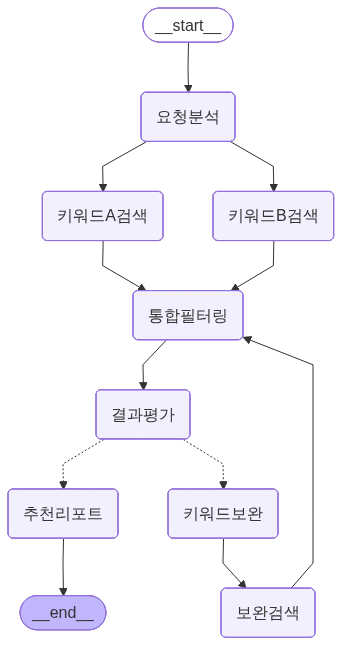

In [19]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    print(app.get_graph().draw_ascii())

---

## Step 5. 실행 테스트

In [20]:
def run(question: str):
    print(f"\n{'='*55}")
    print(f"질문: {question}")
    print('='*55)

    # 초기 State 설정 후 그래프 실행
    result = app.invoke({
        "question":          question,
        "keyword_a":         "",
        "keyword_b":         "",
        "all_products":      [],
        "filtered_products": [],
        "is_sufficient":     False,
        "answer":            "",
        "retry_count":       0,
    })

    total    = len(result["all_products"])      # 전체 수집 상품 수
    filtered = len(result["filtered_products"]) # 중복 제거 후 상품 수
    retry    = result["retry_count"]            # 보완 검색 횟수
    print(f"\n[보완 검색: {retry}회 | 총 수집: {total}개 → 필터: {filtered}개]")
    print(f"\n{result['answer']}")


# 테스트 1: 일반 쇼핑 질문
run("5만원 이하 무선 블루투스 이어폰 추천")


질문: 5만원 이하 무선 블루투스 이어폰 추천
  [요청분석] 키워드 추출 중...
  [요청분석] A='무선 블루투스 이어폰' / B='이어폰'
  [키워드A검색] '무선 블루투스 이어폰' (관련도순)
  [키워드B검색] '이어폰' (가격순)
  [키워드B검색] 5개
  [키워드A검색] 5개
  [통합필터링] 10개 → 중복제거 후 10개
  [결과평가] 10개, 보완=0회 → ✅ 충분
  [결정] 충분 → 추천리포트
  [추천리포트] 작성 중...
  [추천리포트] 완료

[보완 검색: 0회 | 총 수집: 10개 → 필터: 10개]

### 추천 상품 TOP 5
1. **로랜텍 커널형 버즈 무선 블루투스 이어폰 RSM-R510**  
   가격: 19,800원  
   쇼핑몰: 네이버  
   [구매 링크](https://search.shopping.naver.com/catalog/53530143052)

2. **NEW QCY 큐씨와이 AIR 초경량 가성비 음질좋은 블루투스 무선 이어폰 오픈**  
   가격: 21,800원  
   쇼핑몰: 비욘드퍼니싱  
   [구매 링크](https://smartstore.naver.com/main/products/12182776514)

3. **베이스어스 BP1 PRO 노이즈캔슬링 이어폰**  
   가격: 28,900원  
   쇼핑몰: 네이버  
   [구매 링크](https://search.shopping.naver.com/catalog/57474367418)

4. **무통증이어폰1.7m 블랙1개 귓속형 커널형 스마트폰**  
   가격: 10원  
   쇼핑몰: 옥션  
   [구매 링크](https://link.auction.co.kr/gate/pcs?item-no=C251605726&sub-id=1&service-code=10000003)

5. **(이어폰)(줄감개) 무통증 귓속형 오픈형 선정리 와인더 실리콘 ear phone**  
   가격: 10원  
   쇼핑몰: 쿠팡  
   [구매 링크

In [21]:
# 테스트 2: 계절 상품
run("겨울 등산 방수 재킷 추천")


질문: 겨울 등산 방수 재킷 추천
  [요청분석] 키워드 추출 중...
  [요청분석] A='방수 재킷' / B='겨울 등산 의류'
  [키워드A검색] '방수 재킷' (관련도순)
  [키워드B검색] '겨울 등산 의류' (가격순)
  [키워드B검색] 5개
  [키워드A검색] 5개
  [통합필터링] 10개 → 중복제거 후 10개
  [결과평가] 10개, 보완=0회 → ✅ 충분
  [결정] 충분 → 추천리포트
  [추천리포트] 작성 중...
  [추천리포트] 완료

[보완 검색: 0회 | 총 수집: 10개 → 필터: 10개]

### 추천 상품 TOP 5
1. **스타일엣지 하드쉘 바람막이 남성 방수자켓 등산 아웃도어 윈드브레이커**
   - 가격: 48,800원
   - 쇼핑몰: STYLEEDGE
   - [구매 링크](https://smartstore.naver.com/main/products/9036717203)

2. **블랙야크 고어텍스 바람막이자켓 남성 여성 팩커블 등산자켓**
   - 가격: 54,000원
   - 쇼핑몰: 블랙야크 서수원점
   - [구매 링크](https://smartstore.naver.com/main/products/8047916077)

3. **방수자켓 블랙야크 바람막이 남성 AWC 3L 레인 방수자켓**
   - 가격: 107,100원
   - 쇼핑몰: 블랙야크 전주 평화점
   - [구매 링크](https://smartstore.naver.com/main/products/9738248335)

4. **K2 바람막이 아웃도어 방수 자켓 남성 여성 여름 바람막이**
   - 가격: 116,000원
   - 쇼핑몰: 모다 천안아산 K2
   - [구매 링크](https://smartstore.naver.com/main/products/10680329068)

5. **여름바람막이 초경량바람막이 홑겹 아웃도어 방수자켓 여름용 방풍 간절기 작업복**
   - 가격: 15,800원
   - 쇼핑몰: 꽃중년-
   - [구매 링크]

In [22]:
# stream(): 전체 실행 흐름 단계별 확인
print("=== stream()으로 통합 실행 흐름 추적 ===")

for event in app.stream({
    "question":          "가성비 좋은 기계식 키보드",
    "keyword_a":         "",
    "keyword_b":         "",
    "all_products":      [],
    "filtered_products": [],
    "is_sufficient":     False,
    "answer":            "",
    "retry_count":       0,
}):
    # event는 {노드이름: 해당 노드의 출력} 형태
    node_name = list(event.keys())[0]
    output    = event[node_name]

    if "keyword_a" in output and "keyword_b" in output:
        print(f"  [{node_name}] A='{output['keyword_a']}', B='{output['keyword_b']}'")
    elif "all_products" in output:
        print(f"  [{node_name}] {len(output['all_products'])}개 수집")
    elif "filtered_products" in output:
        print(f"  [{node_name}] {len(output['filtered_products'])}개 필터링")
    elif "is_sufficient" in output:
        print(f"  [{node_name}] 충분={output['is_sufficient']}")
    elif "answer" in output:
        print(f"  [{node_name}] 추천 완료")
    else:
        print(f"  [{node_name}] 완료")

=== stream()으로 통합 실행 흐름 추적 ===
  [요청분석] 키워드 추출 중...
  [요청분석] A='기계식 키보드' / B='컴퓨터 주변기기'
  [요청분석] A='기계식 키보드', B='컴퓨터 주변기기'
  [키워드A검색] '기계식 키보드' (관련도순)
  [키워드B검색] '컴퓨터 주변기기' (가격순)
  [키워드A검색] 5개
  [키워드B검색] 5개
  [키워드A검색] 5개 수집
  [키워드B검색] 5개 수집
  [통합필터링] 10개 → 중복제거 후 10개
  [통합필터링] 10개 필터링
  [결과평가] 10개, 보완=0회 → ✅ 충분
  [결정] 충분 → 추천리포트
  [결과평가] 충분=True
  [추천리포트] 작성 중...
  [추천리포트] 완료
  [추천리포트] 추천 완료


In [24]:
# stream(): 최종 추천 결과만 출력
final_answer = ""

for event in app.stream({
    "question":          "가성비 좋은 기계식 키보드",
    "keyword_a":         "",
    "keyword_b":         "",
    "all_products":      [],
    "filtered_products": [],
    "is_sufficient":     False,
    "answer":            "",
    "retry_count":       0,
}):
    for node_name, output in event.items():
        if "answer" in output:
            final_answer = output["answer"]

print(final_answer)

  [요청분석] 키워드 추출 중...
  [요청분석] A='가성비 기계식 키보드' / B='키보드'
  [키워드A검색] '가성비 기계식 키보드' (관련도순)
  [키워드B검색] '키보드' (가격순)
  [키워드A검색] 5개
  [키워드B검색] 5개
  [통합필터링] 10개 → 중복제거 후 10개
  [결과평가] 10개, 보완=0회 → ✅ 충분
  [결정] 충분 → 추천리포트
  [추천리포트] 작성 중...
  [추천리포트] 완료
### 추천 상품 TOP 5
1. **한성 기계식 레트로 저소음 무소음 적축 키보드**  
   가격: 36,000원  
   쇼핑몰: HyunCom  
   [구매 링크](https://smartstore.naver.com/main/products/11574445933)

2. **게이밍 기계식 키보드 앱코 K640 청축**  
   가격: 42,000원  
   쇼핑몰: 드림팩토리샵  
   [구매 링크](https://smartstore.naver.com/main/products/5644036525)

3. **GDEVIL G812 METEOR 파스텔 기계식 키보드**  
   가격: 49,800원  
   쇼핑몰: GDEVIL  
   [구매 링크](https://smartstore.naver.com/main/products/11424351788)

4. **앱코 조약돌 키보드 텐키리스 보글보글 무소음 적축**  
   가격: 59,000원  
   쇼핑몰: 드림팩토리샵  
   [구매 링크](https://smartstore.naver.com/main/products/12319185836)

5. **앱코 조약돌 키보드 기계식 풀배열 보글보글 사무용 적축**  
   가격: 69,900원  
   쇼핑몰: 드림팩토리샵  
   [구매 링크](https://smartstore.naver.com/main/products/12274849130)

### 구매 가이드
- **가격대 요약**: 추천 상품의 가격은 36,000원에서 69

---

## 핵심 정리

01~03의 모든 패턴이 하나의 그래프 안에서 함께 동작합니다.

```python
# ─ 통합 패턴 요약 ──────────────────────────────────────────

# [순차] START → 요청분석 → ...
builder.add_edge(START, "요청분석")

# [병렬 fan-out] 요청분석 → A검색 & B검색 동시 실행
builder.add_edge("요청분석", "키워드A검색")
builder.add_edge("요청분석", "키워드B검색")

# [병렬 fan-in] A, B 모두 완료 후 통합필터링 실행
builder.add_edge("키워드A검색", "통합필터링")
builder.add_edge("키워드B검색", "통합필터링")

# [조건부] 결과평가 → 충분하면 추천, 부족하면 보완
builder.add_conditional_edges("결과평가", decide_after_evaluate)

# [루프] 보완검색 → 다시 통합필터링
builder.add_edge("보완검색", "통합필터링")

# [체인 실행] 2단계로 분리
chain = recommend_prompt | llm | StrOutputParser()
answer = chain.invoke({"question": ..., "products": ...})
```

| 노드 | 역할 | 패턴 |
|---|---|---|
| 요청분석 | LLM으로 검색어 2개 추출 | 순차 |
| 키워드A검색 | 관련도순 검색 | 병렬 (fan-out) |
| 키워드B검색 | 가격순 검색 | 병렬 (fan-out) |
| 통합필터링 | 중복제거 + 정렬 | fan-in |
| 결과평가 | 충분 여부 판단 | 조건부 분기 |
| 검색보완 | 새 키워드 생성 | 루프 |
| 보완검색 | 추가 검색 | 루프 |
| 추천리포트 | 최종 추천 작성 | 순차 |

---

> 01 순차 → 02 병렬 → 03 조건부+루프 → 04 통합  
> 이 4가지 패턴만 있으면 대부분의 LangGraph 애플리케이션을 만들 수 있다.